<div style="text-align: center;padding-top:10px;padding-bottom:10px">
    <a href="https://geostatisticslessons.com/" target="_blank" style="color:#93c6c7" >
    <img src="https://geostatisticslessons.com/favicon-96x96.png" alt="Geostatistics Lessons Link" style="width:100px">
    </a>
</div>

<div style="text-align: center">
    <font style="color:#000000;padding-bottom:-100px"><center><b><font size="+3">Projection Pursuit Multivariate Transform</font></b></center></p>
    <font style="color:#000000;padding-bottom:50px"><center><b><font size="+2">A Companion Notebook to Geostatistics Lessons</font></b></center></p>     
</div>



<p class="author" style="color:#000000;padding: 0;"><left><b>Luis Davila and Ryan Barnett</b></left></p>
<p class="date" style="color:#000000;padding: 0;"><left><b>October 22, 2025</b></left></p>

---

# Outline

The following notebook accompanies the lesson [Projection Pursuit Multivariate Transform](https://geostatisticslessons.com/lessons/ppmt) (PPMT). This companion notebook uses a different dataset and shows a complete multivariate simulation workflow that includes use of the PPMT.

1. **Load Data**
    - Inspect and process data
2. **Despike and Decluster**
    - Despike and decluster to facilitate the normal score (NS) transform that follows
3. **Data Transformations**
    - Perform the NS transform, which is not strictly required, but generally precedes the PPMT for better defining variograms input to simulation
    - Perform the PPMT transform, removing multivariate relations
4. **Variography**
    - Perform variography of the NS data
5. **Simulation**
    - Simulate using the PPMT conditioning data
6. **Back-transformation**
    - Back-transform from PPMT to original units, reintroducing multivariate relations
7. **Result Checking**
    - Section, histogram, variogram, multivariate relations and condition checking
8. **Closing Comments**
    - Summarizes additional considerations for the PPMT and multivariate simulation, that are generally important in practice.

The presented workflow may be extended to represent other deposits. Inline annotations with each step will note practical adjustments that may be necessary for this extension.

Import required packages:

In [1]:
import matplotlib.pyplot as plt
import rmsp

rmsp.activate()
%matplotlib inline

License cleq45ynq00hsgomxw4jmtsvw checked out by clp1l0q1n2347lb22mk5w1a0u to cm5yh1itt25gxal02g56h30hs expires in 43 minutes. RMSP is up to date!


Plot settings:

In [2]:
rmsp.GlobalParams.update(
    {
        "plotting.scatplot.c": "k",
        "plotting.scatplot.alpha": ".3",
        "plotting.scatplot.s": 10,
        "plotting.scatplot.stats": ["corr", "rankcorr"],
        "plotting.scatplot.stats_loc": (0.99, 0.01),
        "plotting.scatplot.stats_va": "bottom",
        "plotting.viewer3d.show_static": True,
    }
)

---
# Load and Process Data

Load example data, returning a `rmsp.PointData` object that contain variables (`CU`, `ELEM_A`, `ELEM_B`, `ELEM_C`) that will be focused on. Note that suitable settings for the variaiables, axis limits, log scaling, etc. are also loaded via `set_params`. This is equivalent to use of the `rmsp.Variable` that is applied further down for setting axis limits, color limits, etc. for a Gaussian variable.

In [3]:
comps = rmsp.load_example_data("copper_composite", set_params=True)
comps.head()

,DHID,FROM,TO,x,y,z,startx,starty,startz,endx,endy,endz,CU,ELEM_A,ELEM_B,ELEM_C,ELEM_D,DENSITY,GEOCODE
0,DDH-0001,0.0,5.0,820.941053,12244.73598,1208.492476,820.945000,12243.87900,1210.841000,820.935784,12245.59520,1206.144771,NaN,NaN,NaN,NaN,NaN,NaN,D
1,DDH-0001,5.0,10.0,820.929193,12246.45665,1203.797888,820.935784,12245.59520,1206.144771,820.921280,12247.32033,1201.451831,NaN,NaN,NaN,NaN,NaN,NaN,D
2,DDH-0001,10.0,15.0,820.912045,12248.18625,1199.106601,820.921280,12247.32033,1201.451831,820.901488,12249.05440,1196.762202,NaN,NaN,NaN,NaN,NaN,NaN,D
3,DDH-0001,15.0,20.0,820.889610,12249.92477,1194.418636,820.901488,12249.05440,1196.762202,820.876410,12250.79738,1192.075906,NaN,NaN,NaN,NaN,NaN,NaN,D
4,DDH-0001,20.0,25.0,820.861888,12251.67222,1189.734015,820.876410,12250.79738,1192.075906,820.846044,12252.54928,1187.392965,NaN,NaN,NaN,NaN,NaN,NaN,D


Define `variables` list and inspect their statistics:

In [4]:
variables = ["CU", "ELEM_A", "ELEM_B", "ELEM_C"]
comps[variables].describe()

,CU,ELEM_A,ELEM_B,ELEM_C
count,499.000000,338.000000,500.000000,498.000000
mean,2.661480,1.292021,46.842177,559.249981
std,2.319725,1.423242,70.481602,949.138792
min,0.000000,0.000000,0.000000,0.000000
25%,0.795872,0.422480,0.000000,57.760000
50%,2.178105,0.897527,17.917526,180.123410
75%,3.914012,1.783776,60.623159,659.451522
max,14.160800,14.849000,505.741000,9879.396000


Simply consider isotopic data in this demonstration. In practice, multiple imputation would be used to generate realizations of the missing values using  `rmsp.GMMImputer`.


In [5]:
comps = comps.get_isotopic_data(variables)
comps[variables].describe()

,CU,ELEM_A,ELEM_B,ELEM_C
count,337.000000,337.000000,337.000000,337.000000
mean,3.111055,1.295855,64.836488,700.791494
std,2.270352,1.423609,77.551332,947.825584
min,0.000000,0.000000,0.000000,7.708000
25%,1.447142,0.423440,14.041460,125.614000
50%,2.783155,0.897750,38.070416,279.354660
75%,4.188841,1.788510,84.650200,993.309960
max,14.160800,14.849000,505.741000,6864.693251


Inspect the multivariate relations, which we will seek to reproduce with this simulation workflow:

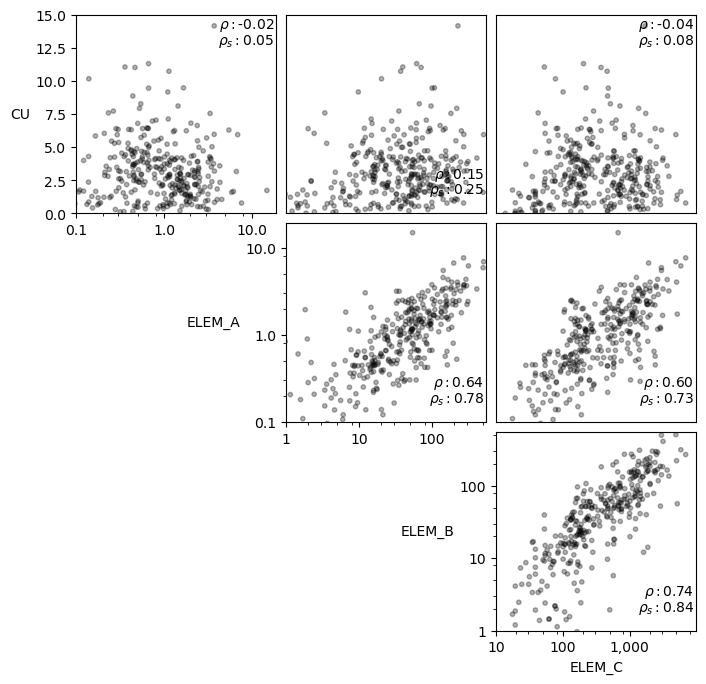

In [6]:
fig = comps.scatplots(variables, figsize=(8, 8))

---
# Despike and Decluster

## Multivariate despiking
Despike the data to consider multivariate correlation and spatial moving average in preparation for the PPMT. Otherwise random breaking of spikes are applied internally by the PPMT, same as the normal score transform.

Detect any spikes:

In [7]:
despike = rmsp.DespikeMVSpatial().fit(comps[variables])
print(
    f"there are {despike.spike_indices.sum(1).sum()} records with spikes"
)

there are 54 records with spikes


Remove the spikes:

In [8]:
temp = despike.transform(comps, variables)
for var, col in zip(variables, temp.columns):
    comps[var] = temp[col]

## Simulation Grid Setup 

Generate a rotated grid from the data:

In [9]:
grid = rmsp.GridData.from_scattered_points(
    comps,
    usize=10.0,
    vsize=5.0,
    zsize=10.0,
    azimuth_deg=10,
    srch_radius=50.0,
    origin=(540.0, 12050.0, 930.0),
)
grid.griddef.to_table()

,Easting (u),Northing (v),Elevation (z)
minimum (m),534.64,11954.64,925.0
maximum (m),1129.82,12407.86,1235.0
size (m),10.0,5.0,10.0
number,54,73,31
origin (m),540.0,12050.0,930.0
rotation (deg),10.0,-,-


Visualize the grid against the data:

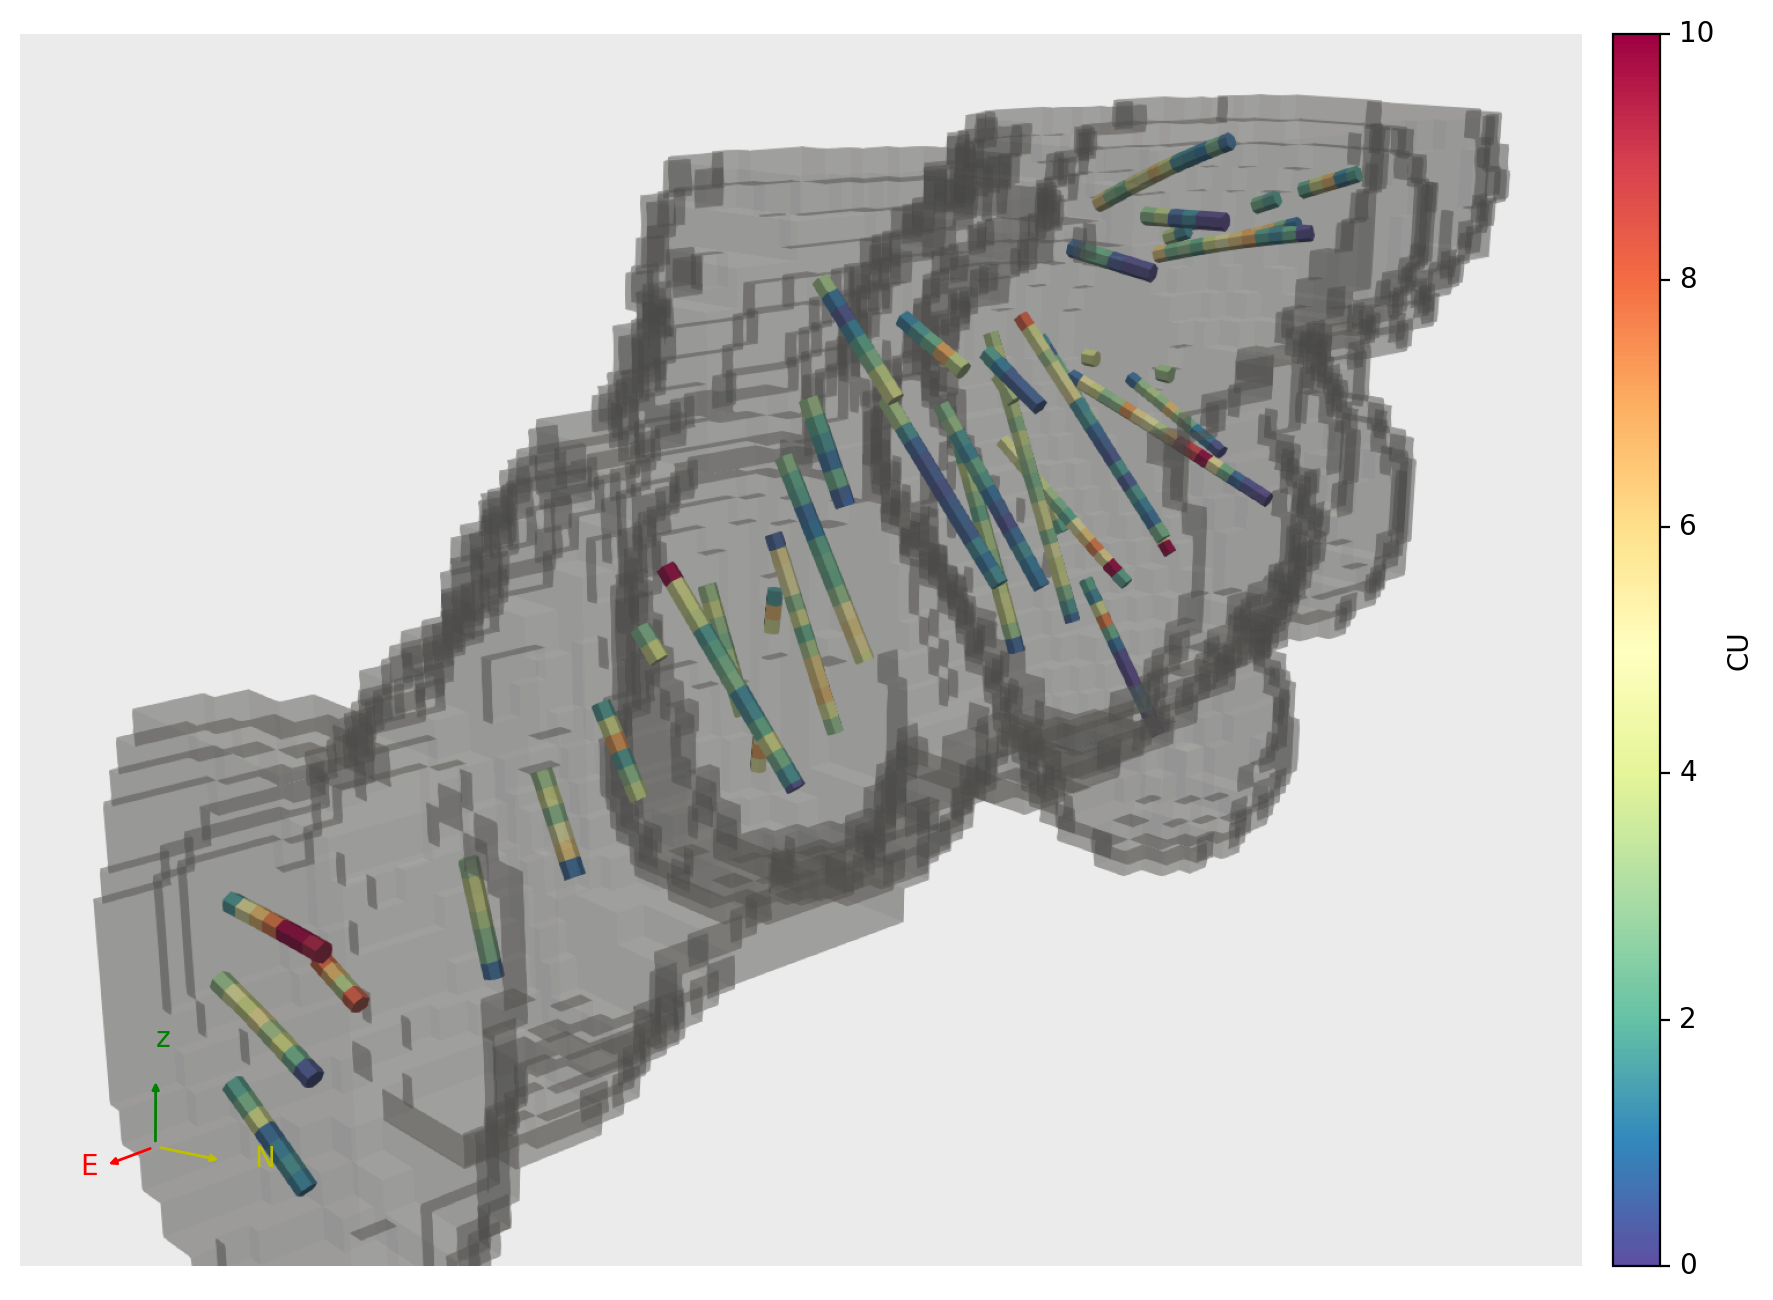

In [10]:
viewer = comps.view3d('CU', representation='Surface')
grid.view3d(color='.5', alpha=0.3, viewer=viewer)
viewer.set_camera(view_matrix=[1487.72,12723.40,1296.23,850.46,12269.13,1085.00,-0.21,-0.16,0.97])

## Declustering

Perform NN declustering. Note that the anisotropy of the search ellipse defined here was previously defined using a neutral model, and it is not shown in this notebook. Also note that declustering weights do not need to be calculated for every variable since the data is isotopic and their anisotropy is reasonably consistent.

In [11]:
searchp = rmsp.Search(
    angles=(190.0, -80.0, 0.0),
    ranges=(1000.0, 1000.0, 400.0)
)
comps["wt"] = rmsp.DeclusterNN(searchp.angles, searchp.ranges).decluster(
    grid, comps
)

Compare the clustered and representative distributions:

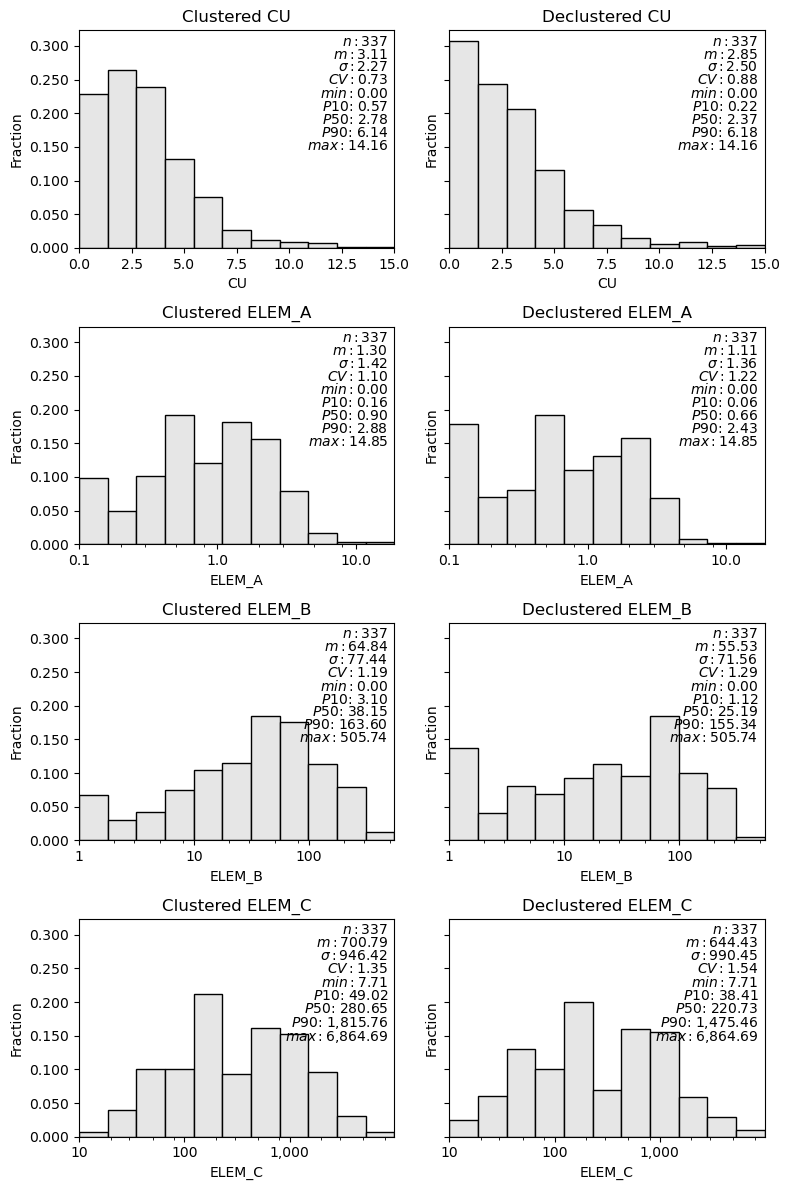

In [12]:
def compare_dists(comps, prefix=""):
    fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharey=True)
    for var, axs in zip(variables, axes):
        comps.histplot(
            prefix + var,
            bin_type="fraction",
            ax=axs[0],
            title="Clustered " + var,

        )
        comps.histplot(
            prefix + var,
            "wt",
            bin_type="fraction",
            ax=axs[1],
            title="Declustered " + var
        )
    fig.tight_layout()


compare_dists(comps)

---
# Data Transformations
## Normal Score Transformation

Apply the normal score (NS) transform, since variogram models used in the simulation of PPMT variables should be fit to normal score variables. Refer to http://geostatisticslessons.com/lessons/ppmt for additional details.

In [13]:
nscorer = rmsp.NSTransformerMV()
temp = nscorer.fit_transform(comps[variables], comps["wt"])
nsvariables = list(temp.columns)
for col in nsvariables:
    comps[col] = temp[col].values
nsvariables

['NS_CU', 'NS_ELEM_A', 'NS_ELEM_B', 'NS_ELEM_C']

Setup plot settings for NS variables, cloning the settings for columns where it should be applied:

In [14]:
ns = rmsp.Variable('NS').set_variable_params(clim=(-3, 3), axis_lim=(-4, 4))
for col in nsvariables:
    ns.clone(col)

Compare marginal distributions with and without declustering weights (declustered is normal since weights used in the PPMT):

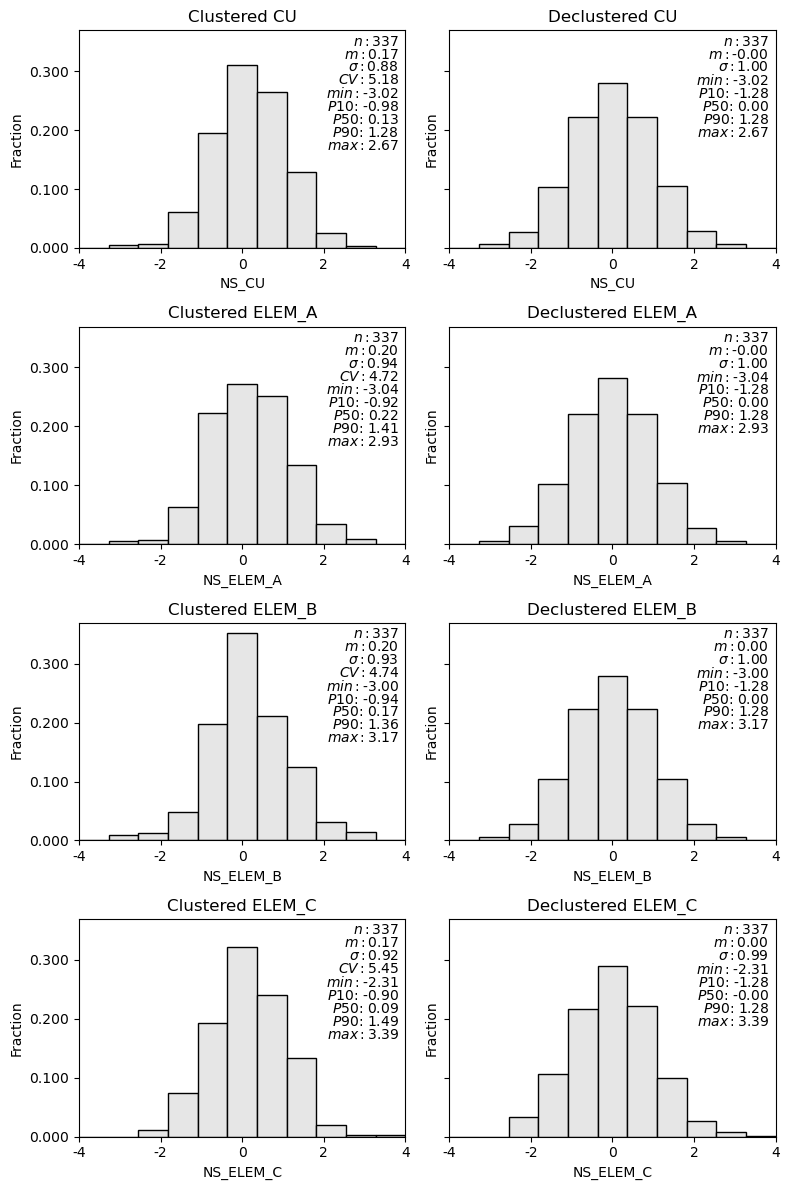

In [15]:
compare_dists(comps, "NS_")

## PPMT

Apply the PPMT to transform the variables to be uncorrelated and multivariate Gaussian. `rmsp.PPMTransformer.fit_transform` performs preprocessing and projection persuit. Empirical distributions are constructed (for pre-processing and projection pursuit) using the standard piecewise-linear approach if not using the hermite polynomials. If using hermite polynomials a KDE should be fit for normal scores transformation. And similarly, if detrending ahead of a hermite PPMT, it is recommended to use a KDE fit for trend transformation, applied internally to SCT.

In [16]:
ppmt = rmsp.PPMTransformer()
temp = ppmt.fit_transform(
    comps[variables],
    comps["wt"],
    target_normality=10,
    min_iters=25,
    max_iters=100,
)
ppmt_vars = list(temp.columns)
for col in ppmt_vars:
    comps[col] = temp[col].values

Check the projection index to understand how the data proceed toward multivariate normality with increasing iterations. In this case, the algorithm terminates before reaching its maximum iterations since it reaches the target normality before. The normality corresponds with the $P_{10}$ of distributions with matching size (the samples are generated using MCS), which means that it is very normal. Note the log axis in this plot:

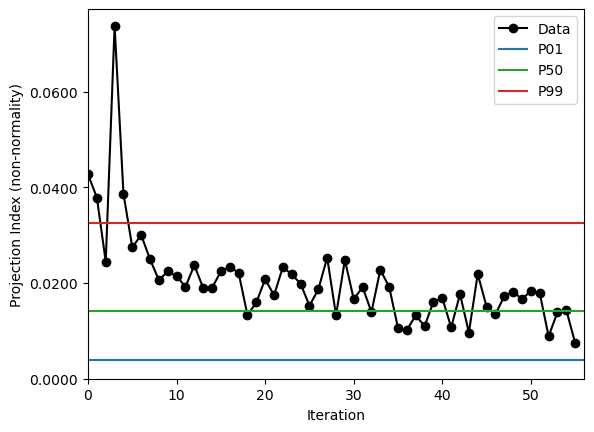

In [17]:
_ = ppmt.plot_normality()

Clone the NS plot settings for the PPMT columns:

In [18]:
for col in ppmt_vars:
    ns.clone(col)

Inspect the data scatter and correlation. Correlation near zero  and circular density contours indicate reasonable bivariate normality, so that independent simulation may be applied:

without weights


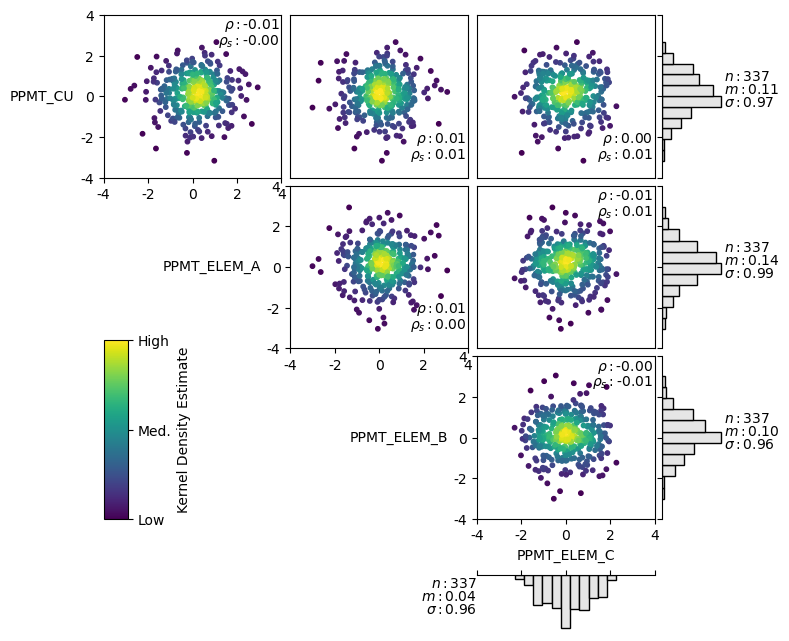

with weights


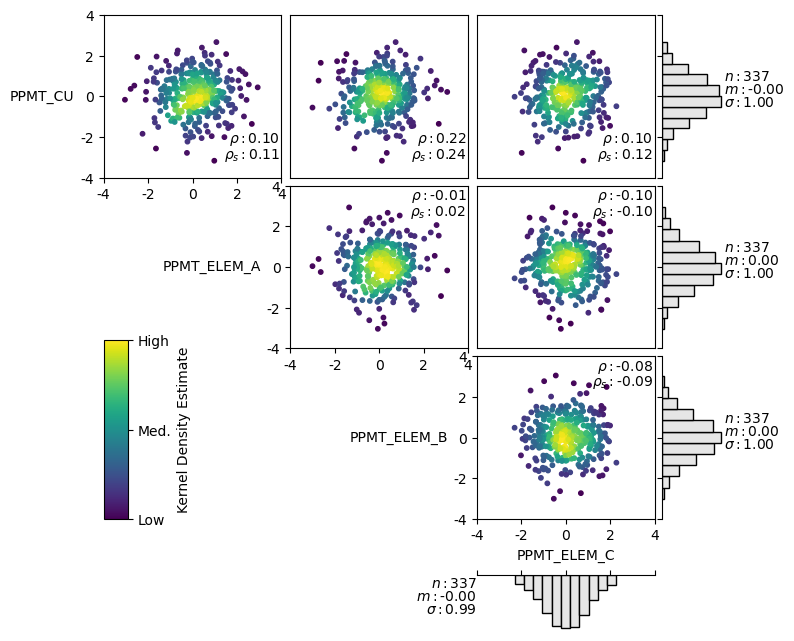

In [19]:
print("without weights")
scatpars = dict(
    c="KDE",
    cbar=True,
    figsize=(8, 8),
    alpha=1,
    plot_marginals=True,
)
fig = comps.scatplots(ppmt_vars, **scatpars)
plt.show()
print("with weights")
fig = comps.scatplots(ppmt_vars, "wt", **scatpars)

Compare marginal distributions with and without declustering weights (declustered is normal since weights used in the PPMT):

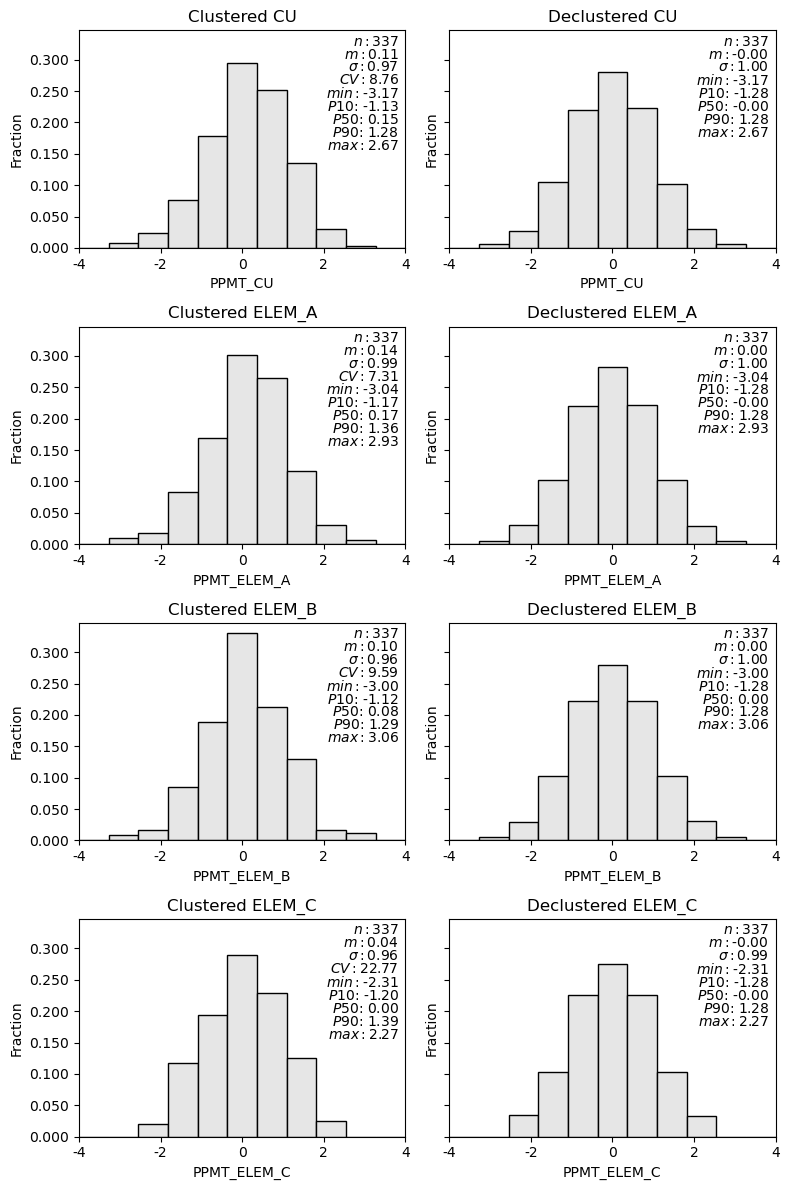

In [20]:
compare_dists(comps, "PPMT_")

---
# Variography

Note that variogram calculations are performed on the normal score data, as prescribed in the lesson.

## Experimental variogram

Calculate experimental normal score variograms. Note that lag distances, merging of omni/directional variograms, and principal directions of anisotropy follow previous realized analysis not shown here since it is not the goal of the lesson.

In [21]:
# Omni-directional and directional searches
search_omni = rmsp.ExpVarioSearch(
    0, 0, rmsp.Lags(4, 2.0, 5), azmtol=90, incltol=90
)
principals = searchp.get_principals()
search_dir = [
    rmsp.ExpVarioSearch(p["azm"], p["incl"], rmsp.Lags(15.0, 20.0, 10))
    for p in principals
]

expvarios_omni = rmsp.FullExpVarios(nsvariables).calculate(
    comps, search_omni
)
expvarios_dir = rmsp.FullExpVarios(nsvariables).calculate(
    comps, search_dir
)

## Variogram modeling and uncertainty accuracy

Fit the experimental variograms with models before checking uncertainty accuracy with leave-one-out-cross-validation. The omni-directional is used indirectly for checking the less informed minor direction, and the nugget effect.

NS_CU


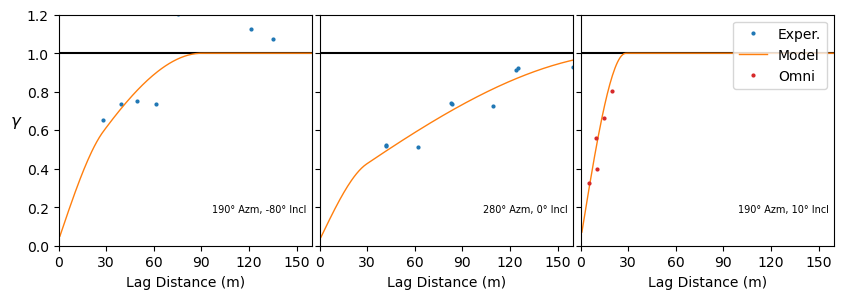

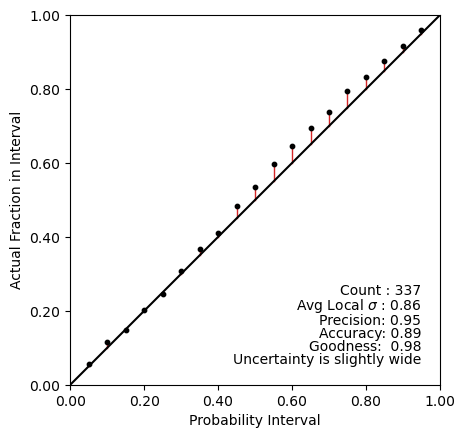

NS_ELEM_A


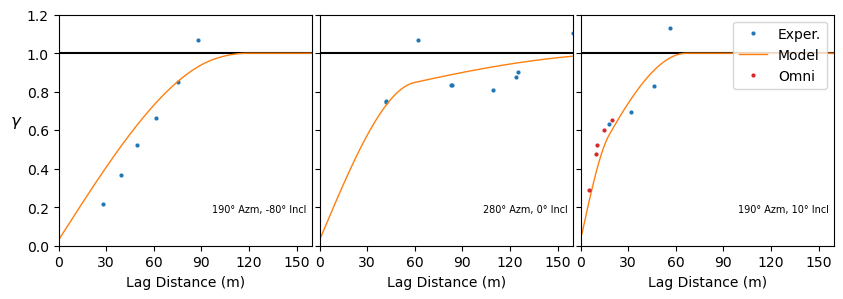

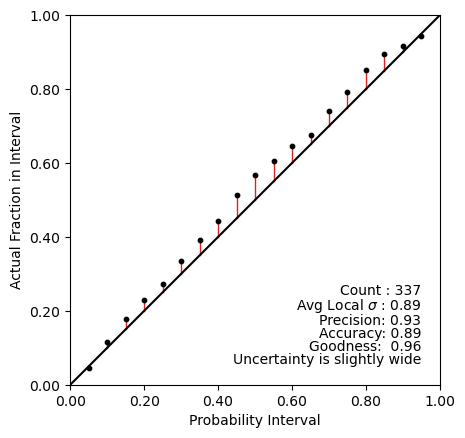

NS_ELEM_B


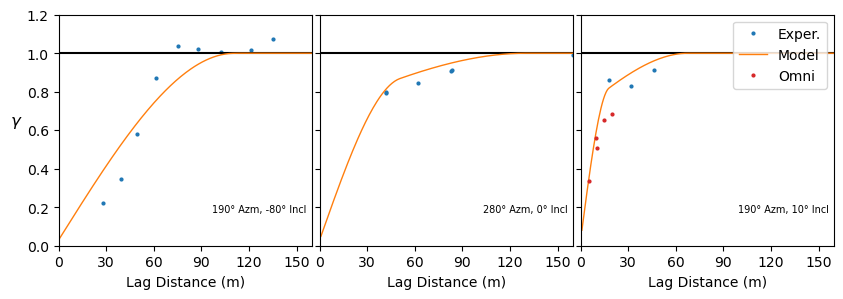

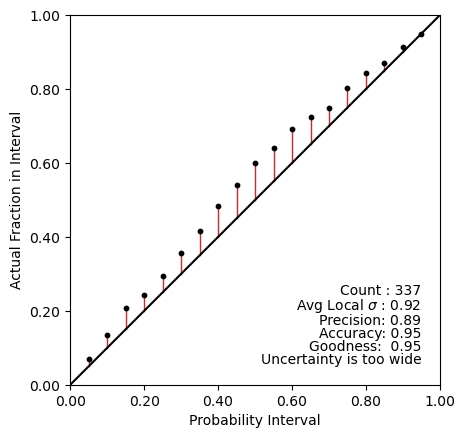

NS_ELEM_C


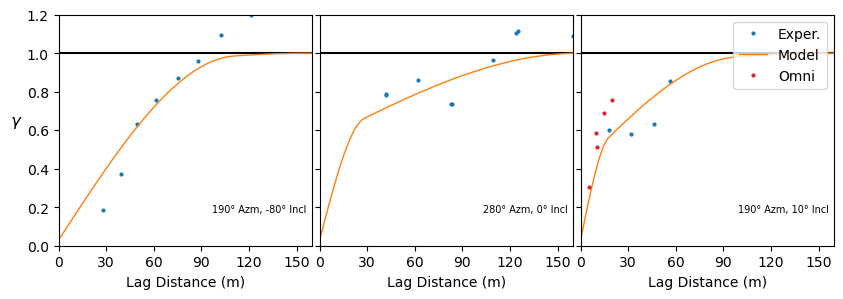

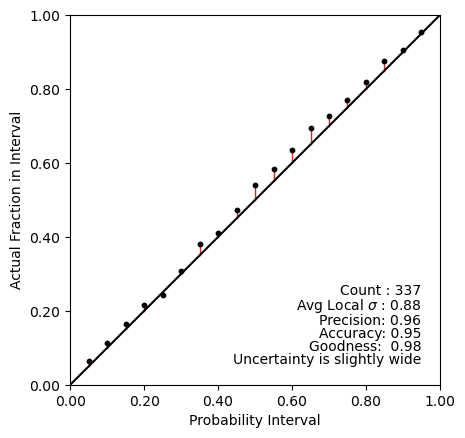

In [22]:
variomods = {}
for var in nsvariables:
    # Fit a model and plot
    print(var)
    variomods[var] = rmsp.VarioModel.fit_experimental(
        expvarios_dir[var],
        nugget=0.03,
        angle1=searchp.angles[0],
        angle2=searchp.angles[1],
        angle3=searchp.angles[2],
        range1=[[10, 200]] * 3,
        range2=[[10, 200]] * 3,
        range3=[[10, 200]] * 3,
    )
    fig, axes = expvarios_dir[var].gridplot(
        figsize=(10, 3),
        model=variomods[var],
        label="Exper.",
        model_kws={"label": "Model"},
    )
    ax = axes[-1]
    expvarios_omni[var].plot_draw(ax, c="C3", label="Omni")
    ax.legend(loc=1)

    # Check uncertainty accuracy
    search = rmsp.Search.from_vario_ranges(variomods[var], max_comps=40)
    estimator = rmsp.KrigeEstimator(
        search, variomods[var], ktype="sk", sk_mean=0.0
    )
    cvdf = estimator.loocv(
        comps, var, output=["estimate", "estimate_var"], by_dhid=True
    )
    _ = rmsp.AccuracyNS(cvdf, "True", "Estimate", "Estimate_var").plot()
    plt.show()

---
# Simulation

The number of realizations to simulate:

In [23]:
num_real = 100

Generate reproducible random number seeds for each variable:

In [24]:
seeds = rmsp.rseeds(len(variables), 515151)

Conditional simulation is performed using the variogram model and conditioning data assembled above.

In [25]:
cache = rmsp.SimCache(len(grid), "simcache/")
for var, seed in zip(variables, seeds):
    search = rmsp.Search.from_vario_buffer(
        variomods["NS_" + var], max_comps=40
    )
    cache = rmsp.Simulator().simulate(
        grid,
        comps,
        "PPMT_" + var,
        search,
        variomods["NS_" + var],
        reals=num_real,
        seed=seed,
        cache=cache,
        cache_var="PPMT_" + var,
        progressbar=True,
    )
cache

                              Value
Realization Length           27,635
Number of Realizations          100
Min Realization Index             0
Max Realization Index            99
Variable 0                  PPMT_CU
Variable 1              PPMT_ELEM_A
Variable 2              PPMT_ELEM_B
Variable 3              PPMT_ELEM_C
Storage Mode                   disk
Disk Path                 simcache/
Keyout                        False
Nested Keyout                 False
Sparse Variables              False

---
# Back-transform

Apply the PPMT to re-introduce the original units and multivariate dependence:

In [26]:
cache = ppmt.inverse_transform_sim(
    cache, ppmt_vars, cache, variables, progressbar=True
)
cache

                              Value
Realization Length           27,635
Number of Realizations          100
Min Realization Index             0
Max Realization Index            99
Variable 0                       CU
Variable 1                   ELEM_A
Variable 2                   ELEM_B
Variable 3                   ELEM_C
Variable 4                  PPMT_CU
Variable 5              PPMT_ELEM_A
Variable 6              PPMT_ELEM_B
Variable 7              PPMT_ELEM_C
Storage Mode                   disk
Disk Path                 simcache/
Keyout                        False
Nested Keyout                 False
Sparse Variables              False

Visualize a couple of realizations with respect to the data using plan sections:

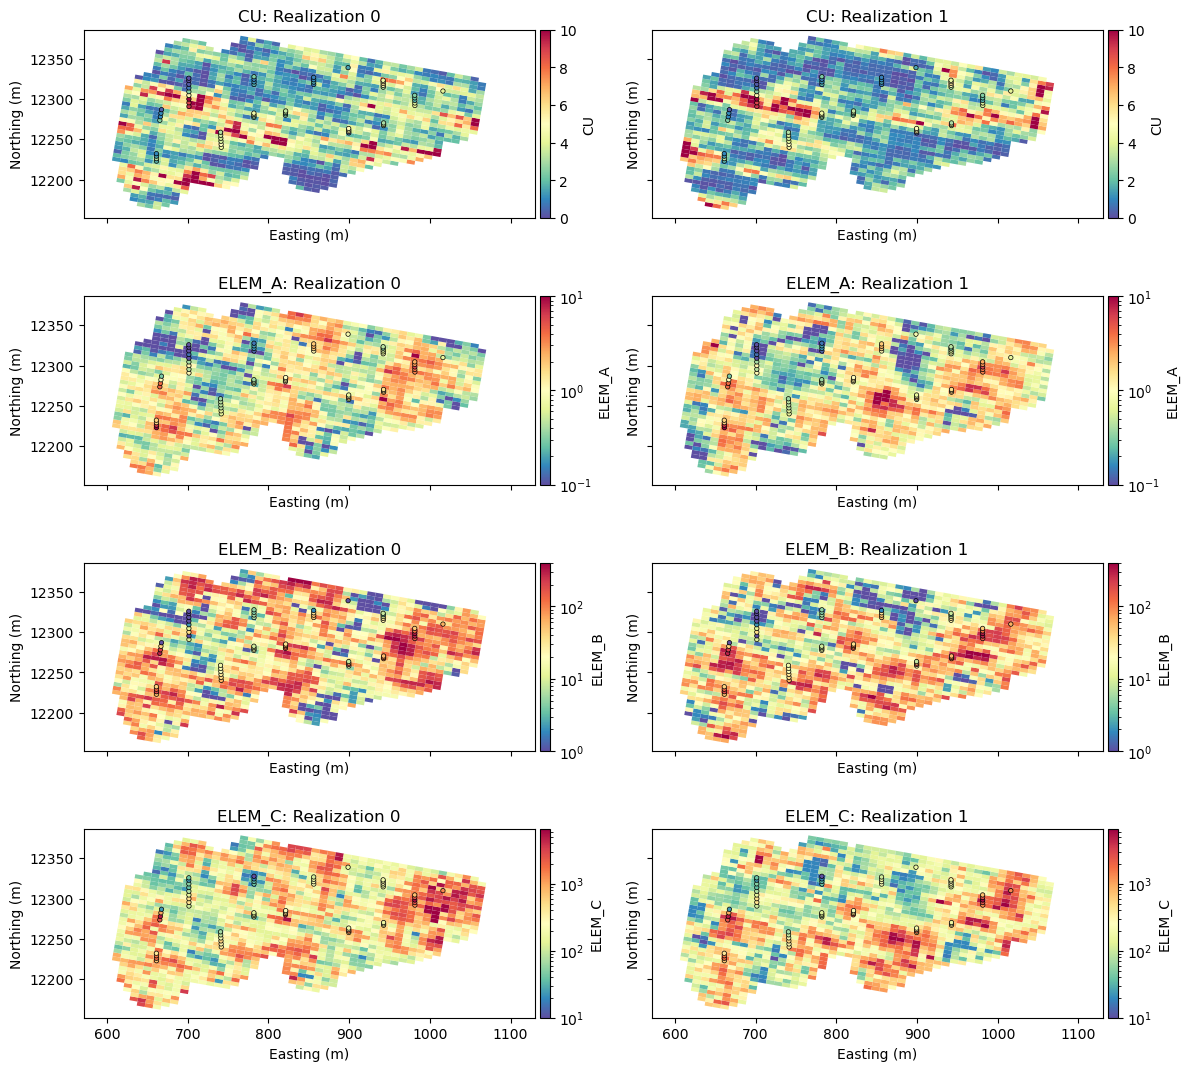

In [27]:
scene = dict(orient="xy", coordinate=comps.spatial_centroid[2])

fig, axes = plt.subplots(4, 2, figsize=(12, 11), sharex=True, sharey=True)
for ireal, axs in enumerate(axes.T):
    real = cache.get_real(ireal, variables, griddef=grid.griddef)
    for var, ax in zip(variables, axs):
        real.sectionplot(
            var,
            ax=ax,
            **scene,
            title=f"{var}: Realization {ireal}",
        )
        comps.sectionplot_draw(
            ax,
            var,
            tolerances=10,
            s=10,
            edgecolors="k",
            **scene,
        )
fig.tight_layout()

---

# Result Checking

## Histogram checking

This reproduction would often be judged acceptable, with good visual reproduction outside of the very lower tail (not log scaling), and the simulated mean with 10% of declustered. That said, it would be noticeably improved with the use of a trend - please see [Trend Modeling and Modeling with a Trend lesson](https://geostatisticslessons.com/lessons/trendmodeling) as reference.

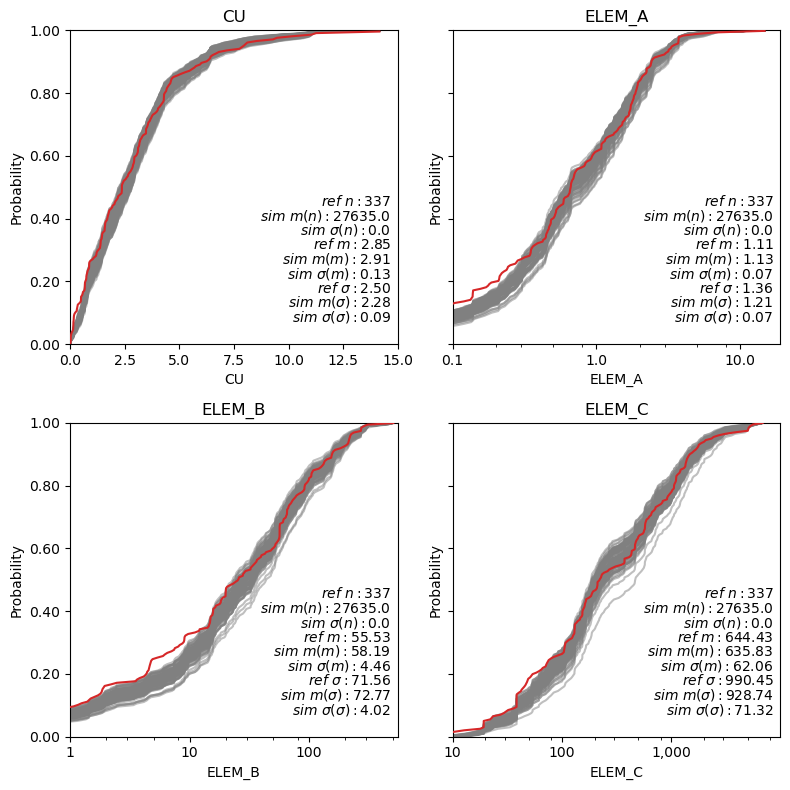

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=True)
for var, ax in zip(variables, axes.flatten()):
    sim_unistats = [
        rmsp.UniStats(cache.get_real(i, var)[var]) for i in range(num_real)
    ]
    rmsp.UniStats(comps[var], comps["wt"]).cdfplot_checkreals(
        sim_unistats, title=var, ax=ax
    )
plt.tight_layout()

## Variogram checking

Setup the gridded search and calculate data variograms in original units:

In [29]:
gridlags, _ = rmsp.Lags(10, 5, 16).get_lags_tols()
gridsearches = [
    rmsp.ExpVarioSearchGrid(p["azm"], p["incl"], gridlags)
    for p in principals
]

expvarios_omni0 = rmsp.FullExpVarios(variables).calculate(
    comps, search_omni
)
expvarios_dir0 = rmsp.FullExpVarios(variables).calculate(comps, search_dir)

Compare against a variogram of the (sparse/clustered) composites, applying the same omni/directional merging approach used in normal scores. The experimental variogram of the data is challenged here by the combination of sparsity and the proportional effect, which could potentially be improved with alternatives to the traditional variogram (e.g., pairwise relative).

CU:


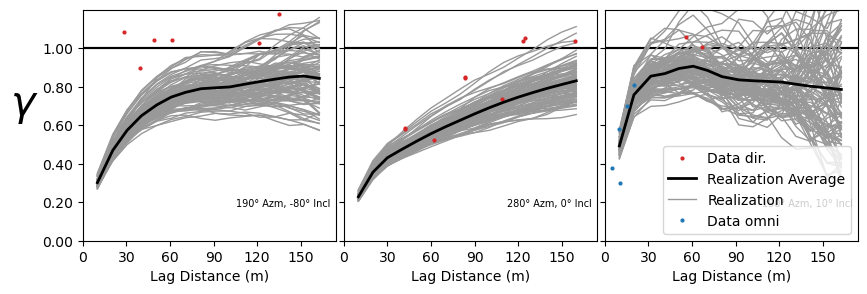

ELEM_A:


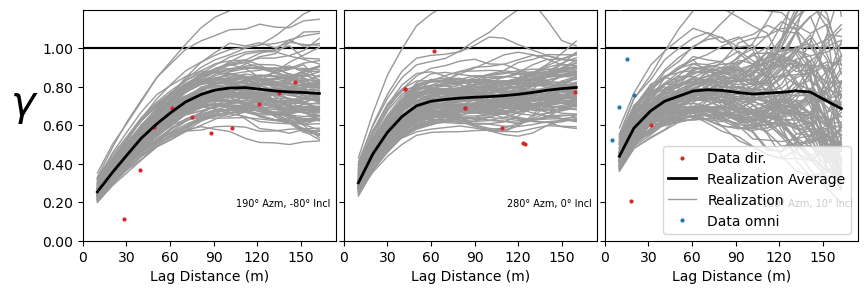

ELEM_B:


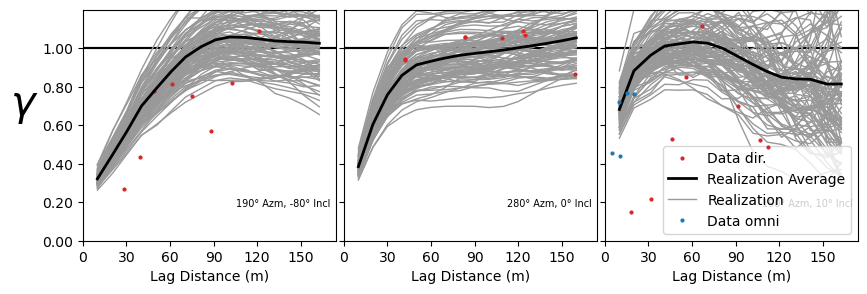

ELEM_C:


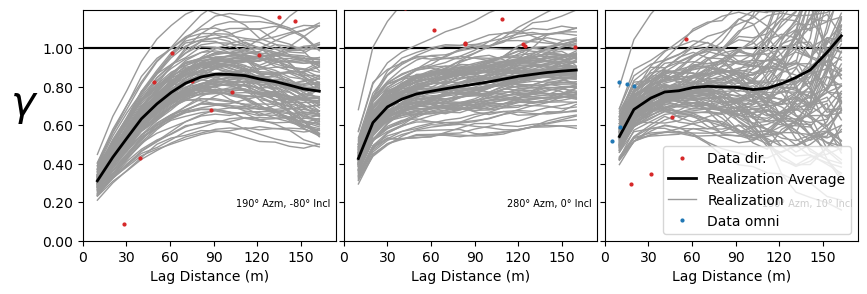

In [30]:
for var in variables:
    print(var + ":")
    gridvario = rmsp.ExpVario(
        standardize=True, sill=rmsp.variance(comps[var], comps["wt"])
    ).calculate_sim(
        cache,
        var,
        gridsearches,
        grid.griddef,
        reals=num_real,
        permit_standardized=True,
    )
    fig, axes = expvarios_dir0[var].gridplot(
        figsize=(10, 3),
        c="C3",
        label="Data dir.",
        model_kws={"label": "Model"},
        zorder=100,
    )
    for i, ax in enumerate(axes):
        gridvario.plot_reals(i, ax=ax, c_avg="k", zorder=-1)
    expvarios_omni0[var].plot_draw(
        ax, c="C0", label="Data omni", zorder=100
    )
    ax.legend(loc=4)
    plt.show()

## Bivariate checking

Compare scatterplots to inspect reproduction of relations. Faint hatching artifacts in the realizations reflect relatively sparse data that define the NS and PPMT transforms. Use of options for avoiding the stepwise empirical distributions implicit to those transforms, through the use of continuous density estimates (`rmsp.KDETransformer` distribution input to `rmsp.NSTransformMV.fit_transform` `num_hermite` argument of `rmsp.PPMTransformer.fit_transform`) would address this issue if deemed problematic.

Data and declustered correlations:


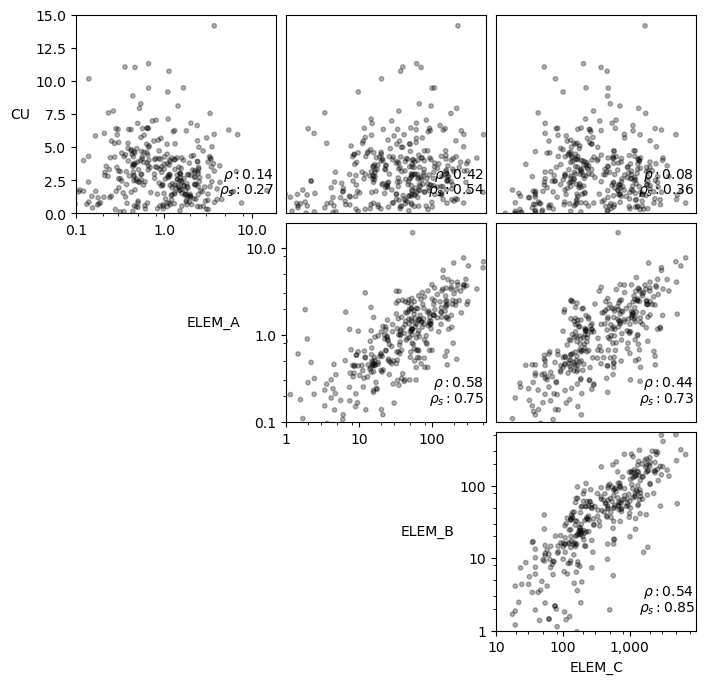

Realization:


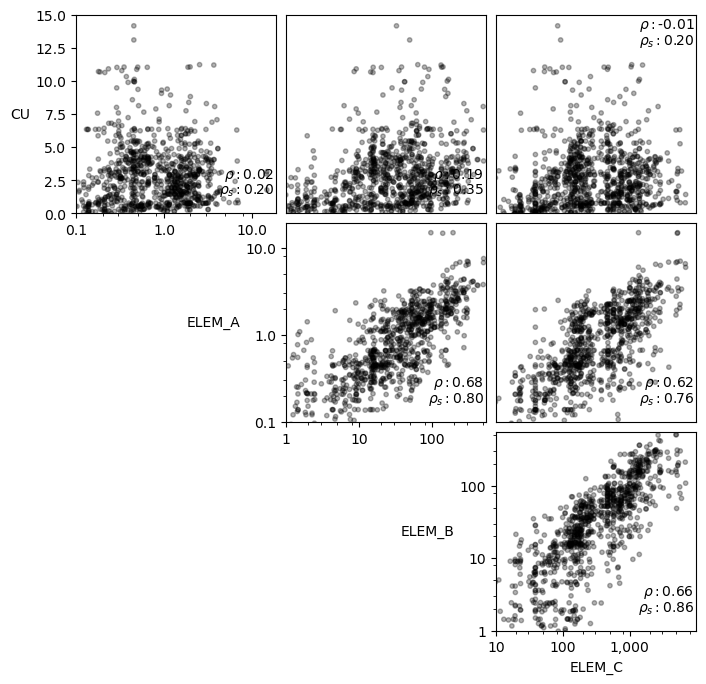

In [31]:
print("Data and declustered correlations:")
fig = comps.scatplots(variables, "wt", figsize=(8, 8))
plt.show()
print("Realization:")
fig = real.scatplots(variables, figsize=(8, 8))

Although correlations are displayed in the scatter plots above, they may more easily compared using correlation matrices: 

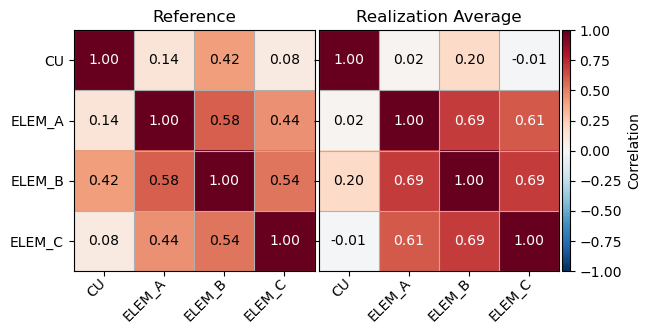

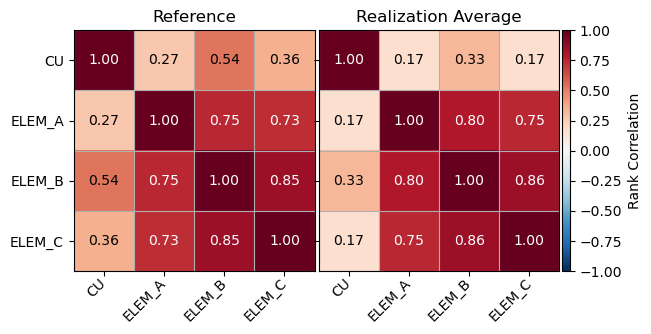

In [32]:
refstats = rmsp.BivStats(comps, variables, "wt")
simstats = [
    rmsp.BivStats(cache.get_real(ireal, variables))
    for ireal in range(num_real)
]
refstats.matrixplot_checkreals(simstats)
_ = refstats.matrixplot_checkreals(simstats, stat="rankcorr")

Check data reproduction, which reflects the use of a coarse grid size (variability between the conditioning values and centroids). Perfect reproduction is not expected as data are not assigned to nodes for turning bands simulation. Instead, correlations and outliers are evaluated.

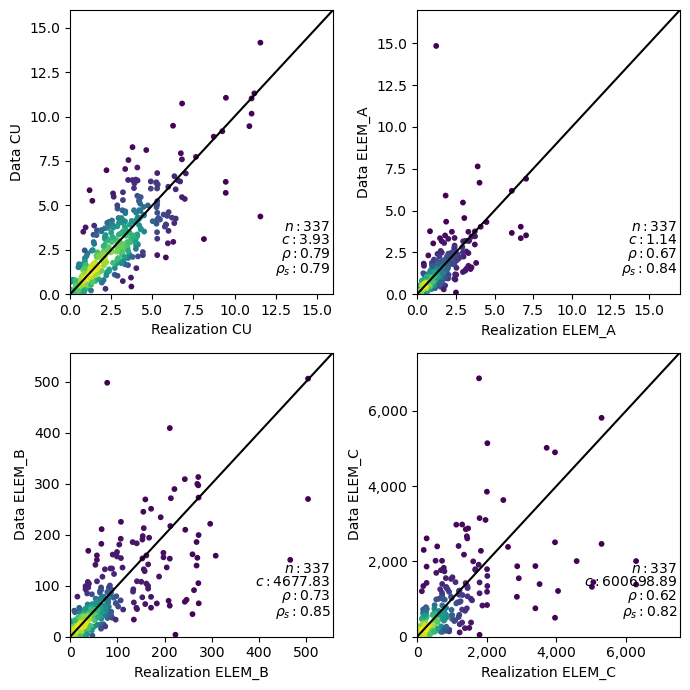

In [33]:
fig, axes = real.scatplot_compare_pointdata(
    variables, comps, grid_prefix="Realization "
)

---
# Closing Comments
This notebook demonstrates concepts that were introduced in the Geostatistics Lesson on Projection Pursuit Multivariate Transform (PPMT) within the context of a multivariate simulation workflow. The PPMT removes potentially complex multivariate dependence, facilitating independent simulation. The inverse transform restores the original multivariate dependencies and units to the realizations. Some practical considerations that were not demonstrated here, include:

- Data imputation is very commonly tied with use of the PPMT or any multivariate transformation (PCA, logratios, etc.), for managing heterotopic (unequally sampled) data. Please refer to Silva, Diogo & Deutsch, Clayton. (2016). Multivariate data imputation using Gaussian mixture models, Spatial Statistics. 27. [10.1016/j.spasta.2016.11.002. ](https://www.researchgate.net/publication/310438329_Multivariate_data_imputation_using_Gaussian_mixture_models/citation/download), which is implemented using `rmsp.GMMImputer`.
- Simulation with a trend is generally essential for reproducing non-stationary features, and has become a staple of modern simulation workflows. A detrending transform would commonly precede the PPMT (e.g., would be chained together) in practice. Please refer to [Trend Modeling and Modeling with a Trend lesson](https://geostatisticslessons.com/lessons/trendmodeling) for more details.
- Using density estimation to smooth empirical distributions that utilized within the normal score and PPMT transforms can be very important for managing stepwise or hatching artifacts. This artifacts may be visually apparent with sparse data, and if concerning, may be managed with KDE and hermite RMSP methods referenced above.

Although this details are important to consider in practice, the simplified example of this notebook aims to show that the PPMT is a practical and powerful approach, particularly where multivariate complexities are prevalent and important to reproduce.


<footer>
<div style="text-align:center">    
    <p style="text-align:center; color:#00797C"> Partners: </p>
    <a href="https://resourcemodelingsolutions.com"><img class="rs" style="max-width:200px;"    src="https://geostatisticslessons.com/images/icons/resource_modeling_solutions_logo.png">
    </a>
    <a  href="https://geostatisticslessons.com/termsofuse"> <p style="text-align:center; color:#00797C">  Terms of Use </p></a>
    <a href="mailto:contact@resmodsol.com"> <p style="text-align:center; color:#00589d">Contact Resource Modeling Solutions about a commercial or academic license for RMSP</p> </a>
</div>
</footer>